### *classification* 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, log_loss

In [2]:
# Function to calculate confusion matrix
def confusion_matrix(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

In [3]:
# Function to calculate accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN)

In [4]:
# Function to calculate precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return TP / (TP + FP) if (TP + FP) > 0 else 0

In [5]:
# Function to calculate recall
def recall(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return TP / (TP + FN) if (TP + FN) > 0 else 0


In [6]:
# Function to calculate F1 score
def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0


In [7]:
# Function to calculate specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    return TN / (TN + FP) if (TN + FP) > 0 else 0

In [8]:
# Function to calculate Matthews Correlation Coefficient (MCC)
def mcc(y_true, y_pred):
    TP, TN, FP, FN = confusion_matrix(y_true, y_pred)
    numerator = (TP * TN) - (FP * FN)
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    return numerator / denominator if denominator > 0 else 0

In [9]:
# Function to evaluate all metrics
def evaluate_metrics(y_true, y_pred, y_prob):
    print("Confusion Matrix: TP, TN, FP, FN")
    print(confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy(y_true, y_pred))
    print("Precision:", precision(y_true, y_pred))
    print("Recall:", recall(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))
    print("Specificity:", specificity(y_true, y_pred))
    print("Cross Entropy Loss:", log_loss(y_true, y_prob))
    print("MCC:", mcc(y_true, y_pred))

In [10]:
# Function to plot ROC curve and print AUC
def plot_roc_and_auc(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

Confusion Matrix: TP, TN, FP, FN
(np.int64(3), np.int64(4), np.int64(1), np.int64(2))
Accuracy: 0.7
Precision: 0.75
Recall: 0.6
F1 Score: 0.6666666666666665
Specificity: 0.8
Cross Entropy Loss: 0.581958147280769
MCC: 0.408248290463863


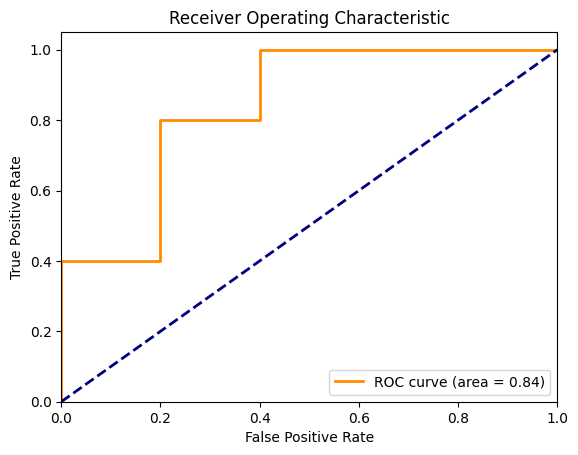

In [13]:
# Example usage
y_true = np.array([0, 1, 0, 1, 0, 1, 0, 1, 1, 0])
y_pred = np.array([0, 1, 0, 0, 0, 1, 1, 1, 0, 0])
y_prob = np.array([0.17, 0.39, 0.29, 0.38, 0.12, 0.87, 0.79, 0.85, 0.25, 0.005])

evaluate_metrics(y_true, y_pred, y_prob)
plot_roc_and_auc(y_true, y_prob)